# YouTube ヒートマップ × 話題セグメント 分析
各セグメント内のヒートマップ値（平均・最大）を集計して表にまとめます。

In [ ]:
# ── 1. インストール ──────────────────────────────────────────
!pip install yt-dlp pandas --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.0 MB/s eta 0:00:00


In [ ]:
# ── 2. 設定：URLとタイムテーブルをここに書く ────────────────────

VIDEO_URL = "https://www.youtube.com/watch?v=pP2KLW-_7hQ"

# セグメント長の下限フィルタ（秒）。これ未満のセグメントは「短すぎ」として別扱い
MIN_DURATION_SEC = 30  # ← ここを変えてください（0 にするとフィルタなし）

# タイムテーブル（開始時刻, 終了時刻）を「分:秒」形式でリスト化
# 元のtxtファイルの内容をそのまま貼り付け
TIMETABLE_RAW = """
0:01:49 0:03:44
0:03:46 0:06:00
0:06:00 0:06:27
0:06:28 0:06:56
0:06:56 0:08:47
0:08:47 0:09:51
0:10:07 0:11:49
0:11:50 0:14:22
0:14:24 0:15:30
0:15:30 0:15:46
0:15:47 0:16:08
0:16:10 0:17:36
0:17:36 0:18:38
0:18:39 0:19:03
0:19:04 0:20:00
0:20:01 0:20:40
0:20:42 0:20:52
0:20:53 0:21:57
0:21:59 0:22:46
0:22:47 0:23:21
0:23:47 0:26:08
0:26:10 0:27:07
0:27:07 0:27:18
0:27:19 0:27:58
0:28:02 0:28:31
0:28:34 0:32:21
0:32:33 0:32:41
0:32:41 0:33:48
0:33:51 0:34:27
0:34:30 0:36:42
0:36:43 0:37:02
0:37:03 0:37:40
0:37:59 0:38:40
0:38:42 0:39:13
0:39:13 0:40:37
0:40:39 0:41:22
0:41:32 0:42:24
0:42:25 0:43:17
0:43:17 0:43:57
0:44:13 0:44:39
0:44:39 0:45:29
0:45:30 0:45:49
0:45:51 0:47:08
0:47:09 0:47:52
0:47:52 0:48:38
0:48:38 0:49:02
0:49:04 0:49:41
0:49:42 0:50:40
0:50:43 0:50:51
0:51:12 0:51:30
0:51:31 0:51:52
0:51:53 0:52:29
0:52:30 0:54:47
0:54:48 0:55:16
0:55:17 0:57:42
0:57:44 0:58:44
0:58:58 0:59:40
0:59:42 1:00:19
1:00:35 1:03:03
1:03:06 1:04:24
1:04:25 1:04:45
1:04:47 1:06:43
1:07:20 1:07:54
1:10:12 1:14:51
"""

In [ ]:
# ── 3. タイムスタンプのパース ─────────────────────────────────

def ts_to_sec(ts: str) -> float:
    """'H:MM:SS' または 'M:SS' を秒数に変換"""
    parts = ts.strip().split(':')
    parts = [int(p) for p in parts]
    if len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    elif len(parts) == 2:
        return parts[0] * 60 + parts[1]
    else:
        return float(parts[0])

def sec_to_ts(sec: float) -> str:
    """秒数を 'H:MM:SS' に変換"""
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h}:{m:02d}:{s:02d}"

segments = []
for line in TIMETABLE_RAW.strip().splitlines():
    line = line.strip()
    if not line:
        continue
    parts = line.split()
    if len(parts) >= 2:
        start_sec = ts_to_sec(parts[0])
        end_sec   = ts_to_sec(parts[1])
        segments.append((start_sec, end_sec))

print(f"セグメント数: {len(segments)}")
print(f"例: {segments[0]} → {sec_to_ts(segments[0][0])} 〜 {sec_to_ts(segments[0][1])}")

セグメント数: 64
例: (109, 224) → 0:01:49 〜 0:03:44


In [ ]:
# ── 4. ヒートマップ取得 ────────────────────────────────────────
import yt_dlp

with yt_dlp.YoutubeDL({'quiet': True}) as ydl:
    info = ydl.extract_info(VIDEO_URL, download=False)

heatmap = info.get('heatmap')
title   = info.get('title', '不明')
duration = info.get('duration', 0)

if not heatmap:
    raise RuntimeError("❌ この動画にはヒートマップデータがありません")

print(f"✅ タイトル : {title}")
print(f"✅ 動画時間 : {sec_to_ts(duration)}")
print(f"✅ ヒートマップ区間数: {len(heatmap)}")

✅ タイトル : 【ひろゆき】子供と大人の勝ち負けの基準。La Virgenを吞みながら。2023/03/28 M20
✅ 動画時間 : 1:42:31
✅ ヒートマップ区間数: 100


In [ ]:
# ── 5. セグメントごとにヒートマップ値を集計 ──────────────────────
#
# 方針: ヒートマップの各区間とセグメントの重複秒数で重み付き平均を計算。
# 重複がない場合は NaN にする（セグメントがヒートマップ範囲外の可能性）。

import pandas as pd
import numpy as np

def calc_segment_stats(seg_start, seg_end, heatmap):
    """
    セグメント [seg_start, seg_end) に重複するヒートマップ区間から
    重み付き平均と最大値を返す。
    """
    values   = []   # ヒートマップ value
    weights  = []   # 重複秒数

    for h in heatmap:
        h_start = h['start_time']
        h_end   = h['end_time']
        overlap = max(0.0, min(seg_end, h_end) - max(seg_start, h_start))
        if overlap > 0:
            values.append(h['value'])
            weights.append(overlap)

    if not values:
        return np.nan, np.nan, 0

    weights = np.array(weights)
    values  = np.array(values)
    weighted_mean = np.average(values, weights=weights)
    max_val       = values.max()
    covered_sec   = weights.sum()
    return weighted_mean, max_val, covered_sec


rows = []
for i, (start, end) in enumerate(segments, 1):
    mean_val, max_val, covered = calc_segment_stats(start, end, heatmap)
    duration_seg = end - start
    vid_id    = info['id']
    start_i   = int(start)
    end_i     = int(end)
    # 通常リンク（開始秒へジャンプ）
    watch_url  = f"https://www.youtube.com/watch?v={vid_id}&t={start_i}s"
    # Notion / Google Forms 埋め込み用（start / end パラメータ付き）
    embed_url  = f"https://www.youtube.com/embed/{vid_id}?start={start_i}&end={end_i}&autoplay=0"
    rows.append({
        'セグメント':          i,
        '開始時刻':            sec_to_ts(start),
        '終了時刻':            sec_to_ts(end),
        '開始(秒)':            start_i,
        '終了(秒)':            end_i,
        '長さ(秒)':            int(duration_seg),
        '平均ヒートマップ値':  round(mean_val, 4) if not np.isnan(mean_val) else None,
        '最大ヒートマップ値':  round(max_val,  4) if not np.isnan(max_val)  else None,
        'YouTube リンク':      watch_url,
        '埋め込みURL':         embed_url,
    })

df = pd.DataFrame(rows)

# ── セグメント長フィルタ適用 ──────────────────────────────────
df['フィルタ区分'] = df['長さ(秒)'].apply(
    lambda s: '✅ 対象' if s >= MIN_DURATION_SEC else f'⚠️ 短い(<{MIN_DURATION_SEC}秒)'
)
df_valid   = df[df['長さ(秒)'] >= MIN_DURATION_SEC].copy()
df_short   = df[df['長さ(秒)'] <  MIN_DURATION_SEC].copy()

print(f"集計完了: 全{len(df)}セグメント  "
      f"→ 対象:{len(df_valid)}件 / 除外({MIN_DURATION_SEC}秒未満):{len(df_short)}件")
print("\n--- 対象セグメント ---")
display(df_valid.reset_index(drop=True))
if len(df_short):
    print(f"\n--- ⚠️ 短すぎて除外 ({MIN_DURATION_SEC}秒未満) ---")
    display(df_short.reset_index(drop=True))

集計完了: 全64セグメント  → 対象:46件 / 除外(30秒未満):18件

--- 対象セグメント ---


,セグメント,開始時刻,終了時刻,開始(秒),終了(秒),長さ(秒),平均ヒートマップ値,最大ヒートマップ値,YouTube リンク,埋め込みURL,フィルタ区分
0,1,0:01:49,0:03:44,109,224,115,0.1206,0.1994,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
1,2,0:03:46,0:06:00,226,360,134,0.0328,0.1674,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
2,5,0:06:56,0:08:47,416,527,111,0.0854,0.3577,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
3,6,0:08:47,0:09:51,527,591,64,0.1731,0.2361,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
4,7,0:10:07,0:11:49,607,709,102,0.0692,0.2361,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
5,8,0:11:50,0:14:22,710,862,152,0.1349,0.1471,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
6,9,0:14:24,0:15:30,864,930,66,0.0571,0.1021,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
7,12,0:16:10,0:17:36,970,1056,86,0.0725,0.1021,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
8,13,0:17:36,0:18:38,1056,1118,62,0.1162,0.3752,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象
9,15,0:19:04,0:20:00,1144,1200,56,0.2558,0.3752,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,✅ 対象



--- ⚠️ 短すぎて除外 (30秒未満) ---


,セグメント,開始時刻,終了時刻,開始(秒),終了(秒),長さ(秒),平均ヒートマップ値,最大ヒートマップ値,YouTube リンク,埋め込みURL,フィルタ区分
0,3,0:06:00,0:06:27,360,387,27,0.2443,0.3577,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
1,4,0:06:28,0:06:56,388,416,28,0.3577,0.3577,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
2,10,0:15:30,0:15:46,930,946,16,0.1021,0.1021,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
3,11,0:15:47,0:16:08,947,968,21,0.1021,0.1021,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
4,14,0:18:39,0:19:03,1119,1143,24,0.3752,0.3752,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
5,17,0:20:42,0:20:52,1242,1252,10,0.0681,0.0681,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
6,23,0:27:07,0:27:18,1627,1638,11,0.0794,0.0794,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
7,25,0:28:02,0:28:31,1682,1711,29,0.1604,0.1604,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
8,27,0:32:33,0:32:41,1953,1961,8,0.3450,0.3450,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)
9,31,0:36:43,0:37:02,2203,2222,19,0.1669,0.2250,https://www.youtube.com/watch?v=pP2KLW-_7hQ&t=...,https://www.youtube.com/embed/pP2KLW-_7hQ?star...,⚠️ 短い(<30秒)


In [ ]:
# ── 6. 平均値でソートしたランキング表示 ───────────────────────────
# df_valid = MIN_DURATION_SEC 以上のセグメントのみ（Cell 5 で生成）
df_ranked = df_valid.sort_values('平均ヒートマップ値', ascending=False).reset_index(drop=True)
df_ranked.index += 1
df_ranked.index.name = 'ランク'

print(f"\n🔥 平均ヒートマップ値ランキング（上位10）  ※{MIN_DURATION_SEC}秒未満は除外済み")
df_ranked[['セグメント','開始時刻','終了時刻','長さ(秒)','平均ヒートマップ値','最大ヒートマップ値']].head(10)


🔥 平均ヒートマップ値ランキング（上位10）


,セグメント,開始時刻,終了時刻,長さ(秒),平均ヒートマップ値,最大ヒートマップ値
ランク,,,,,,
1,14,0:18:39,0:19:03,24,0.3752,0.3752
2,4,0:06:28,0:06:56,28,0.3577,0.3577
3,27,0:32:33,0:32:41,8,0.3450,0.3450
4,49,0:50:43,0:50:51,8,0.3276,0.3276
5,54,0:54:48,0:55:16,28,0.2740,0.2740
6,15,0:19:04,0:20:00,56,0.2558,0.3752
7,64,1:10:12,1:14:51,279,0.2461,0.5215
8,3,0:06:00,0:06:27,27,0.2443,0.3577
9,42,0:45:30,0:45:49,19,0.2365,0.2365


/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 12498 (\N{KATAKANA LETTER HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1063/1206378916.py:23: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND 

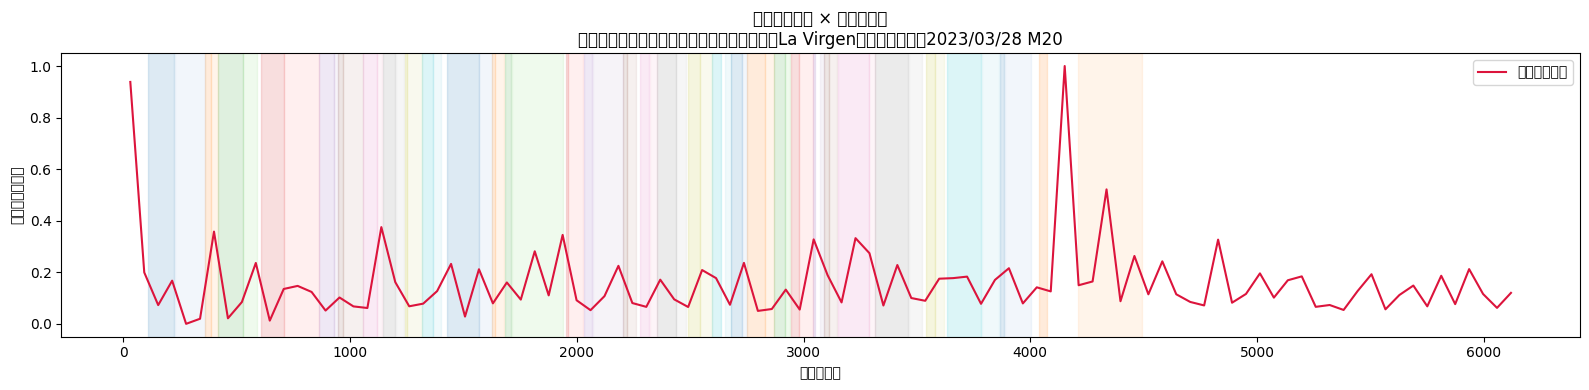

In [ ]:
# ── 7. ヒートマップ全体とセグメントを可視化 ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['font.family'] = 'IPAGothic'  # Colab日本語フォント

# ヒートマップの折れ線
hm_x = [(h['start_time'] + h['end_time']) / 2 for h in heatmap]
hm_y = [h['value'] for h in heatmap]

fig, ax = plt.subplots(figsize=(16, 4))

# セグメントを帯で表示（短すぎるものはグレー）
colors = plt.cm.tab20.colors
valid_set = set(zip(df_valid['開始時刻'], df_valid['終了時刻']))  # type: ignore
for i, (start, end) in enumerate(segments):
    is_short = (end - start) < MIN_DURATION_SEC
    color  = 'gray' if is_short else colors[i % len(colors)]
    alpha  = 0.10   if is_short else 0.18
    ax.axvspan(start, end, alpha=alpha, color=color)

ax.plot(hm_x, hm_y, color='crimson', linewidth=1.5, label='ヒートマップ')
ax.set_xlabel('時間（秒）')
ax.set_ylabel('ヒートマップ値')
ax.set_title(f'ヒートマップ × セグメント\n{title}')
short_patch = mpatches.Patch(color='gray', alpha=0.3, label=f'短すぎ(<{MIN_DURATION_SEC}秒)')
ax.legend(handles=[plt.Line2D([0],[0],color='crimson',lw=1.5,label='ヒートマップ'), short_patch])
plt.tight_layout()
plt.show()

In [ ]:
# ── 8. CSV出力（Colabからダウンロード） ────────────────────────
from google.colab import files

# 出力列の順番を明示（フィルタ区分も含む全件）
csv_cols = [
    'セグメント', '開始時刻', '終了時刻', '開始(秒)', '終了(秒)', '長さ(秒)',
    '平均ヒートマップ値', '最大ヒートマップ値',
    'フィルタ区分', 'YouTube リンク', '埋め込みURL',
]
csv_path = 'heatmap_segments.csv'
df[csv_cols].to_csv(csv_path, index=False, encoding='utf-8-sig')  # BOMつきでExcelでも開ける
files.download(csv_path)
print(f"✅ {csv_path} をダウンロードしました")
print("\n📋 埋め込みURLサンプル（先頭3件）:")
for _, r in df.head(3).iterrows():
    print(f"  [{r['開始時刻']}〜{r['終了時刻']}] {r['埋め込みURL']}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ heatmap_segments.csv をダウンロードしました


In [ ]:
# ── 9. APIから受け取った生データをCSV保存 ────────────────────────
# heatmap: yt-dlpが返したヒートマップの生データ（start_time / end_time / value）
# info   : 動画メタデータ全体

import json as _json
from google.colab import files

# ① ヒートマップ生データ
raw_heatmap_rows = []
for idx, h in enumerate(heatmap, 1):
    raw_heatmap_rows.append({
        '区間番号':     idx,
        '開始時刻':     sec_to_ts(h['start_time']),
        '終了時刻':     sec_to_ts(h['end_time']),
        '開始(秒)':     round(h['start_time'], 4),
        '終了(秒)':     round(h['end_time'],   4),
        '長さ(秒)':     round(h['end_time'] - h['start_time'], 4),
        'value':        h['value'],
    })

df_raw_heatmap = pd.DataFrame(raw_heatmap_rows)
raw_heatmap_path = 'raw_heatmap.csv'
df_raw_heatmap.to_csv(raw_heatmap_path, index=False, encoding='utf-8-sig')
files.download(raw_heatmap_path)
print(f"✅ {raw_heatmap_path} をダウンロードしました ({len(df_raw_heatmap)} 行)")
display(df_raw_heatmap.head())

# ② 動画メタデータ（heatmap フィールドは除外して軽量化）
meta_keys = [
    'id', 'title', 'description', 'upload_date', 'uploader', 'channel_id',
    'duration', 'view_count', 'like_count', 'comment_count',
    'average_rating', 'categories', 'tags', 'webpage_url',
]
meta_row = {}
for k in meta_keys:
    v = info.get(k)
    # list は JSON 文字列にして1セルに収める
    meta_row[k] = _json.dumps(v, ensure_ascii=False) if isinstance(v, list) else v

df_meta = pd.DataFrame([meta_row])
meta_path = 'raw_video_meta.csv'
df_meta.to_csv(meta_path, index=False, encoding='utf-8-sig')
files.download(meta_path)
print(f"\n✅ {meta_path} をダウンロードしました")
display(df_meta.T.rename(columns={0: '値'}))  # 縦向きで見やすく表示


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ raw_heatmap.csv をダウンロードしました (100 行)


,区間番号,開始時刻,終了時刻,開始(秒),終了(秒),長さ(秒),value
0,1,0:00:00,0:01:01,0.00,61.51,61.51,0.938300
1,2,0:01:01,0:02:03,61.51,123.02,61.51,0.199450
2,3,0:02:03,0:03:04,123.02,184.53,61.51,0.072677
3,4,0:03:04,0:04:06,184.53,246.04,61.51,0.167411
4,5,0:04:06,0:05:07,246.04,307.55,61.51,0.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ raw_video_meta.csv をダウンロードしました


,値
id,pP2KLW-_7hQ
title,【ひろゆき】子供と大人の勝ち負けの基準。La Virgenを吞みながら。2023/03/28...
description,やぁやぁ、概要欄だよ。 \n \n働いてない人や子供部屋にいる人向けのビール飲んで雑...
upload_date,20230328
uploader,"ひろゆき, hiroyuki"
channel_id,UC0yQ2h4gQXmVUFWZSqlMVOA
duration,6151
view_count,371392
like_count,2868
comment_count,243
